<a href="https://colab.research.google.com/github/kheirbeqaya/PnP-Camera-Pose-Estimation/blob/main/notebooks/PnP_Camera_Pose_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#              PnP Camera Pose Estimation


# 1. Install dependencies

In [1]:
!pip install opencv-python numpy matplotlib

# 2. Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# 3. Load Image

In [3]:
images = []

for i in range(1, 15):
    if i == 10:
        continue

    url = f"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left{i:02d}.jpg"
    path = f"img_{i}.jpg"

    urllib.request.urlretrieve(url, path)
    img = cv2.imread(path)

    if img is not None:
        images.append(img)

print("Loaded images:", len(images))

Loaded images: 13


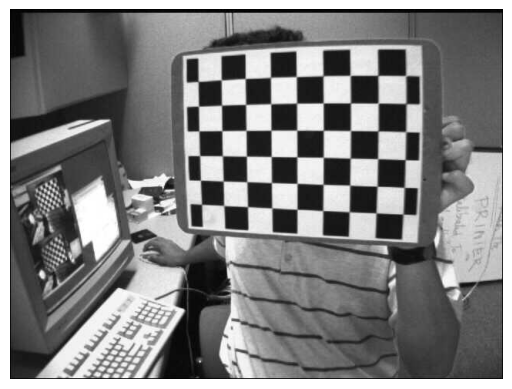

In [4]:
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#4. Checkerboard model

In [5]:
pattern_size = (9, 6)

objp = np.zeros((pattern_size[0]*pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)

# 4. Multi-view detection for corners

In [6]:
objpoints = []
imgpoints = []

img_shape = images[0].shape[:2][::-1]

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, pattern_size)

    if ret:
        corners = cv2.cornerSubPix(
            gray, corners, (11,11), (-1,-1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        )

        objpoints.append(objp)
        imgpoints.append(corners)

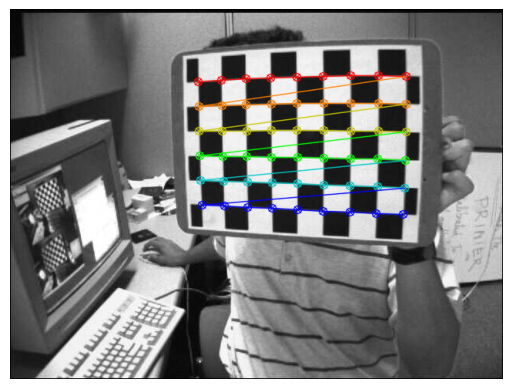

In [7]:
img = images[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, corners = cv2.findChessboardCorners(gray, pattern_size)

corners = cv2.cornerSubPix(
    gray, corners, (11,11), (-1,-1),
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
)

img_corners = img.copy()
cv2.drawChessboardCorners(img_corners, pattern_size, corners, ret)

plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 5. Camera Calibration

In [8]:
ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    img_shape,
    None,
    None
)

print("Camera Matrix:\n", camera_matrix)

Camera Matrix:
 [[536.07345314   0.         342.37046826]
 [  0.         536.01636275 235.53687065]
 [  0.           0.           1.        ]]


# 7. Solve PnP

In [9]:
test_img = images[0]
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

ret, corners = cv2.findChessboardCorners(gray, pattern_size)

corners = cv2.cornerSubPix(
    gray, corners, (11,11), (-1,-1),
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
)

corners_refined = corners

success, rvec, tvec, inliers = cv2.solvePnPRansac(
    objp,
    corners_refined,
    camera_matrix,
    dist_coeffs
)

print("Rotation Vector:\n", rvec)
print("Translation Vector:\n", tvec)

Rotation Vector:
 [[0.16853574]
 [0.27575303]
 [0.01346808]]
Translation Vector:
 [[-3.0111879 ]
 [-4.35756719]
 [15.99287271]]


# 9.Reprojection Error

In [10]:
projected, _ = cv2.projectPoints(
    objp, rvec, tvec, camera_matrix, dist_coeffs
)

error = cv2.norm(corners_refined, projected, cv2.NORM_L2) / len(projected)

print("Reprojection Error:", error)

Reprojection Error: 0.02631453943412056


# 8. Draw Axes

In [11]:
def draw_axes(img, corners, rvec, tvec, camera_matrix, dist_coeffs, length=3):

    axis = np.float32([
        [length,0,0],
        [0,length,0],
        [0,0,-length]
    ])

    imgpts, _ = cv2.projectPoints(axis, rvec, tvec, camera_matrix, dist_coeffs)

    corner = tuple(corners[0].ravel().astype(int))

    img = cv2.line(img, corner, tuple(imgpts[0].ravel().astype(int)), (255,0,0), 3)
    img = cv2.line(img, corner, tuple(imgpts[1].ravel().astype(int)), (0,255,0), 3)
    img = cv2.line(img, corner, tuple(imgpts[2].ravel().astype(int)), (0,0,255), 3)

    return img

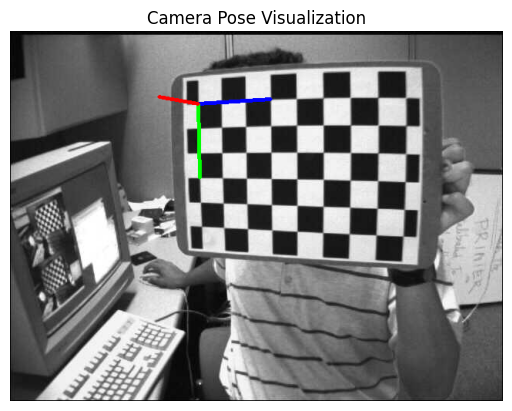

In [12]:
img_axes = draw_axes(
    test_img.copy(),
    corners_refined,
    rvec,
    tvec,
    camera_matrix,
    dist_coeffs
)

plt.imshow(cv2.cvtColor(img_axes, cv2.COLOR_BGR2RGB))
plt.title("Camera Pose Visualization")
plt.axis('off')
plt.show()